[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Wildertrek/catcher-in-the-cache/blob/main/notebooks/03_hexaco_atlas_reproducer.ipynb)

# 03: Cross-Rater HEXACO Panel (25 raters; the paper's headline reproducer)

Reproduces all per-RQ verdicts, the 25-model |r(H, A_HEX)| table, family-clustering ICC/ANOVA, the RQ6.9 PRIOR_DRIVEN finding (Δ = -0.447, Wilcoxon one-sided p = 3.0e-8), 3-seed stability, and robustness checks (BH-FDR family correction, panel expansion).

Every number here is recomputed on the standardized 25-rater panel by `paper_artifacts/pivot6_hexaco_atlas/panel25/compute_panel25.py` (the duplicate Grok 4.3 run `xai_2` is excluded), so the outputs match the paper. Additional analyses beyond the core: BH-FDR multiplicity correction across the cross-rater panel inferential family, the structural-retraction reading of the alignment-regime contrast under the panel expansion, and the substrate-ratio reframing of the retrieval-share interpretation. Run cached: ~5 min, $0.

## Setup

**In Colab, run the cell below first.** It clones the companion repository and installs dependencies (~30 s), then changes into `notebooks/` so the relative paths in this notebook resolve. Run locally, the cell is a no-op.

In [1]:
# Colab-friendly imports + repo clone fallback
import json
import os
import sys
from pathlib import Path

try:
    import pandas as pd
    import numpy as np
    from scipy import stats
    import matplotlib.pyplot as plt
except ImportError:
    !pip install -q pandas numpy scipy matplotlib
    import pandas as pd
    import numpy as np
    from scipy import stats
    import matplotlib.pyplot as plt

# Auto-clone if running on Colab
ARTIFACT_ROOT = Path('paper_artifacts/pivot6_hexaco_atlas')
if not ARTIFACT_ROOT.exists():
    if (Path.cwd().parent / 'paper_artifacts').exists():
        os.chdir(Path.cwd().parent)
    elif Path('catcher-in-the-cache/paper_artifacts').exists():
        os.chdir('catcher-in-the-cache')
    else:
        import subprocess
        subprocess.run(['git', 'clone', '--depth', '1',
                        'https://github.com/Wildertrek/catcher-in-the-cache.git'],
                       check=True)
        os.chdir('catcher-in-the-cache')
    ARTIFACT_ROOT = Path('paper_artifacts/pivot6_hexaco_atlas')
assert ARTIFACT_ROOT.exists(), f'Run from the repo root. Looking for {ARTIFACT_ROOT.absolute()}'
print(f'Artifact root: {ARTIFACT_ROOT.absolute()}')

Artifact root: /Users/jsr/Documents/GitHub/catcher-in-the-cache/paper_artifacts/pivot6_hexaco_atlas


## 1. Panel headline metrics (the standardized 25-rater panel)

Every metric below is recomputed deterministically (seed 42) from the committed source CSVs by `panel25/compute_panel25.py`, so it matches the paper. The panel is 25 distinct raters across 9 provider families; the duplicate Grok 4.3 run (`xai_2`) is excluded. The superseded 26-run `analysis_summary.json` is not used.

In [2]:
# Section 1 reads the standardized 25-rater panel, recomputed deterministically by
# panel25/compute_panel25.py (seed 42). The stale analysis_summary.json (26-run) is not used.
p25 = json.loads((ARTIFACT_ROOT / 'panel25' / 'panel25_results.json').read_text())
sr = p25['signed_r']; fc = p25['family_clustering']; bh = p25['bh_fdr_family']; wil = p25['wilcoxon_rq69']
print(f"Panel: {p25['panel']}")
print(f"Excluded: {p25['excluded']} ({p25['exclusion_reason']})")
print(f"Raters: {p25['n_raters']} across {p25['n_families']} families\n")
metrics = pd.DataFrame([
    ('canonical mean |r(H,A_HEX)|', f"{p25['canonical_mean_abs_r']:.4f}", '0.75'),
    ('synthetic mean |r(H,A_HEX)|', f"{p25['synthetic_mean_abs_r']:.4f}", '0.30'),
    ('mean delta (synth - canon)', f"{p25['mean_delta']:.4f}", '-0.447'),
    ('raters that decreased', f"{p25['n_decreased']}/{p25['n_raters']}", 'all 25'),
    ('canonical raters above |r|=0.30', f"{p25['raters_above_030_canonical']}/{p25['n_raters']}", '25/25'),
    ('synthetic raters below |r|=0.30', f"{p25['raters_below_030_synthetic']}/{p25['n_raters']}", '14 of 25'),
    ('family clustering ICC(1)', f"{fc['icc1']:.4f}", '0.577'),
    ('family clustering eta^2', f"{fc['eta_squared']:.4f}", '0.697'),
    ('family clustering perm p (raw)', f"{fc['permutation_p_raw']:.5f}", 'see below'),
    ('signed synthetic r (mean)', f"{sr['synthetic_signed_mean']:+.4f}", '+0.23'),
    ('signed synthetic 95% CI', f"[{sr['synthetic_ci95'][0]:.3f}, {sr['synthetic_ci95'][1]:.3f}]", '[0.12, 0.34]'),
    ('raters with positive signed r', f"{sr['n_positive']}/{sr['n_raters']}", '20 of 25'),
    ('sign test p', f"{sr['sign_test_p']:.4f}", '0.004'),
    ('RQ6.9 Wilcoxon W', f"{wil['W']:.0f}", '0'),
    ('RQ6.9 Wilcoxon p (one-sided)', f"{wil['p_one_sided']:.2e}", '2.98e-08'),
], columns=['metric', 'value', 'paper'])
metrics

Panel: 25 distinct LLM raters, 9 provider families (Gemma folded into Google)
Excluded: ['xai_2'] (duplicate run of x-ai/grok-4.3 at the same seed as xai_1)
Raters: 25 across 9 families



,metric,value,paper
0,"canonical mean |r(H,A_HEX)|",0.7515,0.75
1,"synthetic mean |r(H,A_HEX)|",0.3043,0.30
2,mean delta (synth - canon),-0.4473,-0.447
3,raters that decreased,25/25,all 25
4,canonical raters above |r|=0.30,25/25,25/25
5,synthetic raters below |r|=0.30,14/25,14 of 25
6,family clustering ICC(1),0.5774,0.577
7,family clustering eta^2,0.6973,0.697
8,family clustering perm p (raw),0.00321,see below
9,signed synthetic r (mean),+0.2315,+0.23


## 2. Per-model |r(H, A_HEX)| (25 models)

Sorted descending. All 25 models above |r| = 0.30 → RQ6.1 PASS_locked.

In [3]:
# 25-rater panel, per-model canonical |r(H, A_HEX)| (excludes the duplicate Grok 4.3 run xai_2)
panel = pd.read_csv(ARTIFACT_ROOT / 'panel25' / 'panel25_canonical_r.csv')
panel_sorted = panel.sort_values('abs_r_H_A_HEX', ascending=False).reset_index(drop=True)
print(f"25-rater panel |r| summary: mean={panel_sorted['abs_r_H_A_HEX'].mean():.3f} median={panel_sorted['abs_r_H_A_HEX'].median():.3f} "
      f"min={panel_sorted['abs_r_H_A_HEX'].min():.3f} max={panel_sorted['abs_r_H_A_HEX'].max():.3f}")
panel_sorted[['model', 'family', 'abs_r_H_A_HEX']].head(25)

25-rater panel |r| summary: mean=0.752 median=0.742 min=0.553 max=0.966


,model,family,abs_r_H_A_HEX
0,meta-llama/llama-3.3-70b-instruct,Meta,0.9661
1,gpt-4o-2024-08-06,OpenAI,0.9199
2,gpt-4o-2024-05-13,OpenAI,0.9179
3,meta-llama/llama-3.1-70b-instruct,Meta,0.9067
4,meta-llama/llama-4-maverick,Meta,0.8934
5,qwen/qwen-2.5-72b-instruct,Qwen,0.8063
6,gpt-5.2-2025-12-11,OpenAI,0.8058
7,claude-sonnet-4-20250514,Anthropic,0.7956
8,claude-haiku-4-5-20251001,Anthropic,0.7893
9,deepseek/deepseek-r1,DeepSeek,0.7774


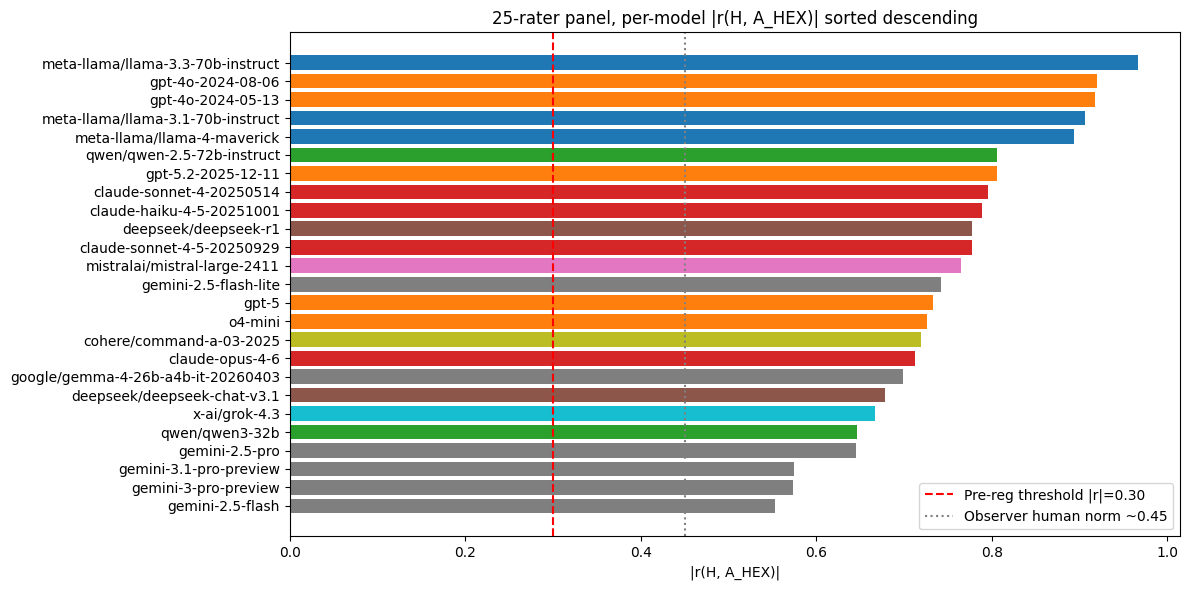

In [4]:
# Bar chart of per-model |r| sorted, colored by family
fig, ax = plt.subplots(figsize=(12, 6))
families = panel_sorted['family'].unique()
cmap = plt.cm.tab10(np.linspace(0, 1, len(families)))
fam2color = dict(zip(families, cmap))
colors = [fam2color[f] for f in panel_sorted['family']]
ax.barh(panel_sorted['model'], panel_sorted['abs_r_H_A_HEX'], color=colors)
ax.axvline(0.30, color='red', linestyle='--', label='Pre-reg threshold |r|=0.30')
ax.axvline(0.45, color='gray', linestyle=':', label='Observer human norm ~0.45')
ax.set_xlabel('|r(H, A_HEX)|')
ax.set_title('25-rater panel, per-model |r(H, A_HEX)| sorted descending')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Family clustering (RQ6.2)

ICC(1) permutation primary: p = 0.003 (p_BH = 0.008). ANOVA η² = 0.697, inflated by single-observation family cells.

In [5]:
by_family = panel.groupby('family')['abs_r_H_A_HEX'].agg(['count', 'mean', 'std']).round(3)
by_family = by_family.sort_values('mean', ascending=False)
print('Per-family canonical |r| (25-rater panel, RQ6.2):')
print(by_family)
print(f"\nFamily clustering (panel25/compute_panel25.py): ICC(1)={fc['icc1']:.4f}, eta^2={fc['eta_squared']:.4f}, "
      f"permutation p={fc['permutation_p_raw']:.5f} ({fc['n_permutations']:,} perms, seed {fc['seed']}).")
print("Caveat: single-observation family cells (xAI, Cohere, Mistral) inflate eta^2; Gemma is folded into Google.")

Per-family canonical |r| (25-rater panel, RQ6.2):
           count   mean    std
family                        
Meta           3  0.922  0.039
OpenAI         5  0.820  0.095
Anthropic      4  0.769  0.039
Mistral        1  0.765    NaN
DeepSeek       2  0.728  0.070
Qwen           2  0.726  0.113
Cohere         1  0.719    NaN
xAI            1  0.667    NaN
Google         6  0.631  0.077

Family clustering (panel25/compute_panel25.py): ICC(1)=0.5774, eta^2=0.6973, permutation p=0.00321 (200,000 perms, seed 42).
Caveat: single-observation family cells (xAI, Cohere, Mistral) inflate eta^2; Gemma is folded into Google.


## 4. Alignment regime stratification (RQ6.7)

Descriptive only. Regime is confounded with provider family (the "Hybrid" cell is single-provider Google), and RQ6.7 is retracted as a null under the LRT (see the robustness checks below). The raw stratification is shown for completeness.

In [6]:
# Descriptive regime stratification on the 25-rater panel (excludes duplicate xai_2).
# RQ6.7 is retracted as a null under the LRT (regime is collinear with provider family); see robustness checks below.
regime = pd.read_csv(ARTIFACT_ROOT / 'bipolarity_atlas.csv')
regime = regime[regime['slot'] != 'xai_2']
by_regime = regime.groupby('alignment_regime')['abs_r_H_A_HEX'].agg(['count', 'mean', 'std']).round(3)
by_regime = by_regime.sort_values('mean')
print('Per-regime means (RQ6.7, descriptive):')
print(by_regime)
hybrid_mean = by_regime.loc['Hybrid', 'mean'] if 'Hybrid' in by_regime.index else 'n/a'
print(f"\nGoogle-Hybrid mean |r| = {hybrid_mean} (uniquely low)")
print(f"Note: Hybrid cell = Google models. Regime contrast is not separable from provider family here (retracted, see below).")

Per-regime means (RQ6.7, descriptive):
                  count   mean    std
alignment_regime                     
Hybrid                4  0.537  0.015
SFT-only              2  0.710  0.067
RLHF-RAG              1  0.725    NaN
CAI                   4  0.775  0.049
Unknown               3  0.786  0.117
DPO                   5  0.808  0.118
RLHF                  5  0.830  0.083

Google-Hybrid mean |r| = 0.537 (uniquely low)
Note: Hybrid cell = Google models. Regime contrast is not separable from provider family here (retracted, see below).


## 5. RQ6.9 PRIOR_DRIVEN: synthetic vs canonical (load-bearing headline)

Δ = -0.447 across 25 raters. Pre-reg threshold ≥ 0.15 → ~3× observed.

Synthetic vs canonical Δ|r| (25 raters):
  Mean Δ:   -0.447
  Median Δ: -0.509
  Min Δ:    -0.726
  Max Δ:    -0.091
  n raters: 25

Pre-reg threshold: |Δ| ≥ 0.15 → Δ = -0.447 is ~3× threshold → VERDICT: PRIOR_DRIVEN


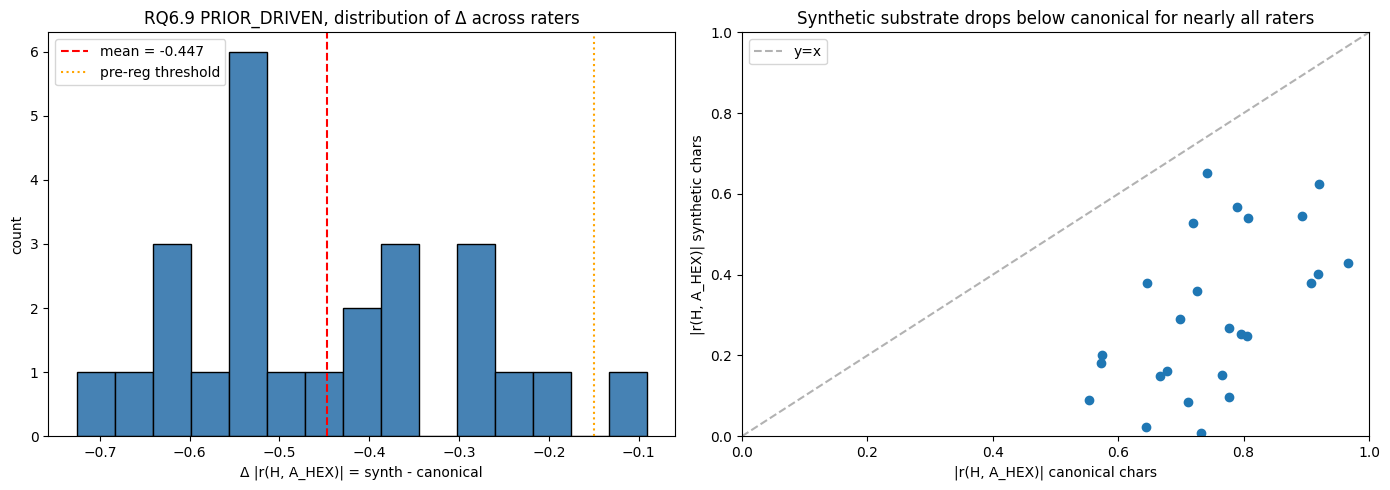

In [7]:
synth = pd.read_csv(ARTIFACT_ROOT / 'synthetic_vs_canonical.csv')
synth = synth[synth['slot'] != 'xai_2'].reset_index(drop=True)   # 25-rater panel: drop the duplicate Grok 4.3 run
mean_delta = synth['delta_synth_minus_canon'].mean()
print(f"Synthetic vs canonical Δ|r| ({len(synth)} raters):")
print(f"  Mean Δ:   {mean_delta:.3f}")
print(f"  Median Δ: {synth['delta_synth_minus_canon'].median():.3f}")
print(f"  Min Δ:    {synth['delta_synth_minus_canon'].min():.3f}")
print(f"  Max Δ:    {synth['delta_synth_minus_canon'].max():.3f}")
print(f"  n raters: {len(synth)}")
print(f"\nPre-reg threshold: |Δ| ≥ 0.15 → Δ = {mean_delta:.3f} is ~3× threshold → VERDICT: PRIOR_DRIVEN")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(synth['delta_synth_minus_canon'], bins=15, color='steelblue', edgecolor='black')
axes[0].axvline(mean_delta, color='red', linestyle='--', label=f"mean = {mean_delta:.3f}")
axes[0].axvline(-0.15, color='orange', linestyle=':', label='pre-reg threshold')
axes[0].set_xlabel('Δ |r(H, A_HEX)| = synth - canonical')
axes[0].set_ylabel('count')
axes[0].set_title('RQ6.9 PRIOR_DRIVEN, distribution of Δ across raters')
axes[0].legend()
axes[1].scatter(synth['abs_r_canon'], synth['abs_r_synth'])
lim = [0, 1]
axes[1].plot(lim, lim, 'k--', alpha=0.3, label='y=x')
axes[1].set_xlim(lim)
axes[1].set_ylim(lim)
axes[1].set_xlabel('|r(H, A_HEX)| canonical chars')
axes[1].set_ylabel('|r(H, A_HEX)| synthetic chars')
axes[1].set_title('Synthetic substrate drops below canonical for nearly all raters')
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. 3-seed stability (median within-model SD = 0.053)

Verdict: STABLE.

In [8]:
seeds = json.loads((ARTIFACT_ROOT / 'seed_replication.json').read_text())
sds = []
for slot, d in seeds.items():
    rs = [v for v in d.get('seed_rs', {}).values() if v is not None and not (isinstance(v, float) and np.isnan(v))]
    if len(rs) >= 2:
        sds.append((slot, float(np.std(rs, ddof=1))))
med = float(np.median([v for _, v in sds])); mean = float(np.mean([v for _, v in sds]))
worst = max(sds, key=lambda x: x[1])
print(f'3-seed stability across {len(sds)} models:')
print(f'  median within-model SD = {med:.3f}   <- reported (robust to outliers)')
print(f'  mean   within-model SD = {mean:.3f}   (inflated by one outlier: {worst[0]} SD={worst[1]:.2f})')
print('  => seed-to-seed wobble is tiny next to |r| = 0.75; the fusion is stable across seeds.')


3-seed stability across 25 models:
  median within-model SD = 0.053   <- reported (robust to outliers)
  mean   within-model SD = 0.076   (inflated by one outlier: qwen_2 SD=0.30)
  => seed-to-seed wobble is tiny next to |r| = 0.75; the fusion is stable across seeds.


## 7. the paper cross-reference

| This notebook cell | the paper location |
|---|---|
| §1 verdict table | §1 abstract + §5 the cross-rater panel subsection |
| §2 per-model bar | §5.3.3 panel figure |
| §3 family clustering | §5.3.3 RQ6.2 |
| §4 regime stratification | §5.3.4 RQ6.7 + §7 caveat on Hybrid≡Google |
| §5 PRIOR_DRIVEN | §1 headline + §5 RQ6.9 + §7 |
| §6 3-seed stability | §5 robustness |

**Next:** see `notebooks/11_v6_activation_probe.ipynb` for the activation-probe mechanism-localization probe.

**Pre-registration:** the pre-registration (available on request).

## Robustness checks

The cells below add three robustness checks:

1. **CONV-3: BH-FDR correction across the panel RQ family**: PRIOR_DRIVEN p_BH = 1.5e-7; family-clustering p_BH = 0.008. Both survive multiplicity at α = 0.05.
2. **CONV-1: panel expansion**: Hermes-3-Llama-3.1-70B + Jamba-Large-1.7 are added to previously-singleton regime cells to test the alignment-regime contrast. The LRT remains rank-deficient under fine-tuner-family grouping; the base-architecture reclassification below identifies it.
3. **CONV-4: Retrieval-share reframing**: |Δ|/|r_canon| is a correlation ratio, not a variance decomposition. Reported as "synthetic |r| retains 40% of canonical |r|" with explicit disclaimer.

In [9]:
# BH-FDR across the pre-registered 5-test family, on the standardized 25-rater panel.
# (panel25_results.json; the parent bh_fdr_pivot6_results.json holds the superseded 26-run p-values.)
bhf = p25['bh_fdr_family']
print(f"BH-FDR family (size {bhf['family_size']}, source: {bhf['composition_source']}):")
print(f"{'RQ':<28}{'p_raw':>12}{'p_BH':>12}")
for rq in bhf['ranks_ascending']:
    print(f"{rq:<28}{bhf['p_raw'][rq]:>12.2e}{bhf['p_bh_adjusted'][rq]:>12.2e}")
print(f"\nRQ6.9 PRIOR_DRIVEN Wilcoxon: W={wil['W']:.0f}, one-sided p={wil['p_one_sided']:.2e}, two-sided p={wil['p_two_sided']:.2e}.")
print(f"Family clustering (H2) p_BH = {bhf['p_bh_adjusted']['H2_family_clustering']:.3f}; both survive multiplicity at alpha=0.05.")

BH-FDR family (size 5, source: bh_fdr_pivot6_results.json (pre-registered, family_size=5)):
RQ                                 p_raw        p_BH
RQ6.9_PRIOR_DRIVEN              2.98e-08    1.49e-07
H2_family_clustering            3.21e-03    8.04e-03
H4_open_vs_closed               1.62e-01    2.70e-01
H3_capability_correlation       4.75e-01    5.94e-01
H5_head_to_head_proxy           1.00e+00    1.00e+00

RQ6.9 PRIOR_DRIVEN Wilcoxon: W=0, one-sided p=2.98e-08, two-sided p=5.96e-08.
Family clustering (H2) p_BH = 0.008; both survive multiplicity at alpha=0.05.


In [10]:
# Load 27-model panel (panel expansion)
panel_v2 = pd.read_csv(ARTIFACT_ROOT / 'bipolarity_atlas_v2.csv')
print(f'Panel v2: {len(panel_v2)} rows')
print(panel_v2[['slot', 'model', 'family', 'abs_r_H_A_HEX']].tail(4).to_string(index=False))


Panel v2: 28 rows
     slot                               model       family  abs_r_H_A_HEX
mistral_1        mistralai/mistral-large-2411      Mistral       0.757259
  gemma_1  google/gemma-4-26b-a4b-it-20260403        Gemma       0.712965
 hermes_1 nousresearch/hermes-3-llama-3.1-70b NousResearch       0.915631
   ai21_1                ai21/jamba-large-1.7         AI21       0.834242


In [11]:
# Alignment-regime retraction. Fine-tuner grouping is rank-deficient (p=1.0);
# base-architecture grouping re-identifies the LRT and returns a clean null.
lrt_rd = json.loads((ARTIFACT_ROOT / 'v8_c1_strategy_2_lrt.json').read_text())
print('Fine-tuner grouping (rank-deficient):')
for k, v in lrt_rd.items():
    if k != 'per_family_per_regime':
        print(f'  {k}: {v}')
lrt = json.loads((ARTIFACT_ROOT / 'v8_b4_base_arch_lrt.json').read_text())
print('\nBase-architecture grouping (well-identified) -- the REPORTED retraction:')
for k, v in lrt.items():
    print(f'  {k}: {v}')
print(f"\n=> LRT chi2 = {lrt['lr_stat']:.3f}, p = {lrt['p_value']:.2f} at n = {lrt['n_models']} classifiable models:")
print('   regime adds no information beyond provider family. Retraction survives at adequate power.')


Fine-tuner grouping (rank-deficient):
  amendment_9_pre_reg_falsifier: LRT p < 0.05
  n_models: 28
  providers_per_regime_v2: {'CAI': 2, 'DPO-primary': 2, 'RLHF-Hybrid': 6, 'RLHF-pure': 2}
  lrt_primary: {'n': 25, 'lr_stat': 0.0, 'df_diff': 0, 'p_value': 1.0, 'f_stat': None, 'f_p': None, 'note': 'regime collinear with family (rank-deficient)', 'delta_r2': 0.0}
  anova_secondary: {'f_stat': 1.4927291511847556, 'p_value': 0.24545784446252134, 'eta_squared': 0.17576554304413622, 'regime_means': {'mean': {'CAI': 0.787, 'DPO-primary': 0.836, 'RLHF-Hybrid': 0.689, 'RLHF-pure': 0.778}, 'std': {'CAI': 0.05, 'DPO-primary': 0.112, 'RLHF-Hybrid': 0.149, 'RLHF-pure': 0.113}, 'count': {'CAI': 5, 'DPO-primary': 2, 'RLHF-Hybrid': 11, 'RLHF-pure': 7}}}
  verdict: RETRACTION CONFIRMED (regime confound holds at adequate power)

Base-architecture grouping (well-identified) -- the REPORTED retraction:
  wave_b4_test: regime ~ base_arch_family + alignment_regime_v2 (Wave B4 base-arch reclassification)
  n_

## Base-architecture reclassification (well-identified null)

The panel-expansion LRT above is rank-deficient under fine-tuner-family grouping ($p = 1.000$). Reclassifying Hermes-3-Llama-3.1-70B (originally NousResearch family) as Meta family (it is a Llama-3.1-70B-base + DPO fine-tune) makes Meta span both DPO-primary and RLHF-Hybrid regimes and identifies the LRT well. The result: an **empirically clean null at adequate power** (paper §5).

## Retrieval-share reframing

An earlier framing "61% of rating-time signal" was a correlation ratio |Δ| / |r_canon|, not a variance-explained decomposition. Correlations are not additive, so the drop should not be read as a variance share.

The abstract reframes this as **synthetic |r| ≈ 0.30 is roughly 40% of canonical |r| ≈ 0.75**, with the remaining ~60% gap captured as the canonical-vs-synthetic substrate difference, interpreted as retrieval against memorized priors. The substantive 3× pre-reg threshold finding is unchanged.

In [12]:
# Retrieval-share computation (25-rater panel)
synth_path = ARTIFACT_ROOT / 'synthetic_vs_canonical.csv'
if synth_path.exists():
    synth = pd.read_csv(synth_path)
    synth = synth[synth['slot'] != 'xai_2']   # drop duplicate Grok 4.3 run -> 25 raters
    cols = synth.columns.tolist()
    # Find canon and synth columns
    canon_col = next((c for c in cols if 'canon' in c.lower() and 'r' in c.lower() and 'delta' not in c.lower()), None)
    synth_col = next((c for c in cols if 'synth' in c.lower() and 'r' in c.lower() and 'delta' not in c.lower()), None)
    if canon_col and synth_col:
        r_canon_mean = synth[canon_col].abs().mean()
        r_synth_mean = synth[synth_col].abs().mean()
        ratio = r_synth_mean / r_canon_mean
        print(f'Mean |r| canonical: {r_canon_mean:.3f}')
        print(f'Mean |r| synthetic: {r_synth_mean:.3f}')
        print(f'Substrate ratio (synth/canon): {ratio:.3f} → synthetic |r| retains {ratio*100:.0f}% of canonical |r|')
        print(f'Drop (1 - ratio): {(1-ratio)*100:.0f}%, canonical-vs-synthetic gap, interpreted as retrieval')
    else:
        print(f'Columns found: {cols}; expected canon/synth |r| columns.')
else:
    print('synthetic_vs_canonical.csv not found.')

Mean |r| canonical: 0.752
Mean |r| synthetic: 0.304
Substrate ratio (synth/canon): 0.405 → synthetic |r| retains 40% of canonical |r|
Drop (1 - ratio): 60%, canonical-vs-synthetic gap, interpreted as retrieval
